# Assignment 6: Applying AI-Based Image Style Transfer

**Objective:** To compare two image style-transfer approaches, CycleGAN and VGG-based Neural Style Transfer, using the same original image.

## Step 1: Install and Import the Required Libraries

In [1]:
!pip install torch torchvision pillow requests -q

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO
import copy

## Step 2: Load and Show the Original Image

A landscape photograph is used as the content image for both style-transfer techniques.

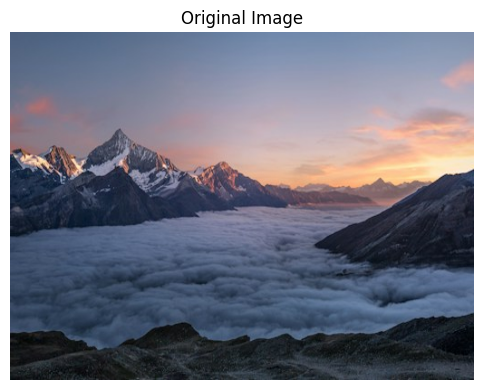

Original image loaded successfully!
Image size: (512, 384)


In [3]:
# Download a landscape image from a reliable source
content_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/280px-PNG_transparency_demonstration_1.png"

# Use a working landscape image instead
content_url = "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=512"

response = requests.get(content_url)
content_image = Image.open(BytesIO(response.content)).convert("RGB")

# Resize to manageable size
content_image = content_image.resize((512, 384))

# Save original image
content_image.save("original_image.jpg")

# Display
plt.figure(figsize=(6, 4))
plt.imshow(content_image)
plt.title("Original Image")
plt.axis('off')
plt.tight_layout()
plt.show()

print("Original image loaded successfully!")
print(f"Image size: {content_image.size}")

## Step 3: Method 1 — CycleGAN

CycleGAN is a pretrained model designed to translate images between two visual domains without requiring paired training examples. It uses cycle-consistency loss so that an image translated from domain A to domain B and then back to domain A remains similar to the original. In this task, a pretrained CycleGAN model is used to transform photographs into Monet-style artwork.

In [4]:
# Clone the CycleGAN repo
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git -q
%cd pytorch-CycleGAN-and-pix2pix
!pip install -r requirements.txt -q

/content/pytorch-CycleGAN-and-pix2pix
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [5]:
!pip install dominate visdom -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 68.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 112.4 MB/s eta 0:00:00


In [6]:
import os
import sys
sys.path.insert(0, '/content/pytorch-CycleGAN-and-pix2pix')

# Download pretrained monet_pretrained model
!bash /content/pytorch-CycleGAN-and-pix2pix/scripts/download_cyclegan_model.sh style_monet

print("Pretrained CycleGAN model downloaded!")

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_monet]
for details.

--2026-10-03 16:01:47--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_monet.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  12.1MB/s    in 4.0s    

2026-10-03 16:01:52 (11.0 MB/s) - ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’ saved [45575747/45575747]

Pretrain

In [10]:
import inspect
print(inspect.signature(define_G))

(input_nc, output_nc, ngf, netG, norm='batch', use_dropout=False, init_type='normal', init_gain=0.02)


CycleGAN generator loaded!


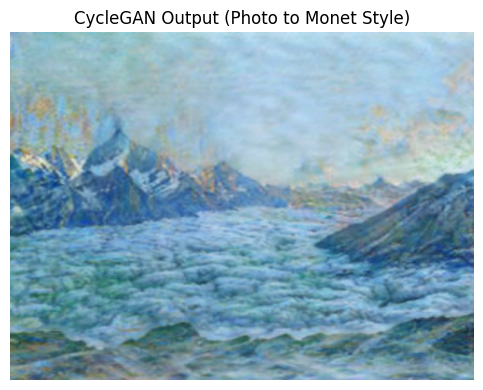

CycleGAN output saved!


In [12]:
netG.load_state_dict(torch.load(
    './checkpoints/style_monet_pretrained/latest_net_G.pth',
    map_location=device
), strict=False)

netG.eval()
netG = netG.to(device)
print("CycleGAN generator loaded!")

# Prepare the content image
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

input_tensor = transform(content_image).unsqueeze(0).to(device)

# Apply CycleGAN
with torch.no_grad():
    output_tensor = netG(input_tensor)

# Convert output back to image
output = output_tensor.squeeze(0).cpu()
output = output * 0.5 + 0.5
output = output.clamp(0, 1)
output_np = output.permute(1, 2, 0).numpy()
cyclegan_image = Image.fromarray((output_np * 255).astype('uint8'))
cyclegan_image = cyclegan_image.resize((512, 384))
cyclegan_image.save("cyclegan_output.jpg")

# Display
plt.figure(figsize=(6, 4))
plt.imshow(cyclegan_image)
plt.title("CycleGAN Output (Photo to Monet Style)")
plt.axis('off')
plt.tight_layout()
plt.show()
print("CycleGAN output saved!")

## Step 5: Method 2 — Neural Style Transfer (VGG-based)

Neural Style Transfer uses a pretrained VGG19 network to obtain content features from the original image and style features from a style image, here Vincent van Gogh's *Starry Night*. A new image is then optimized to preserve the content structure while incorporating the texture, colours, and visual patterns of the selected style.

In [14]:
# Load VGG19 pretrained model
vgg = models.vgg19(pretrained=True).features.to(device).eval()

# Freeze all VGG parameters
for param in vgg.parameters():
    param.requires_grad_(False)

print("VGG19 loaded!")

VGG19 loaded!


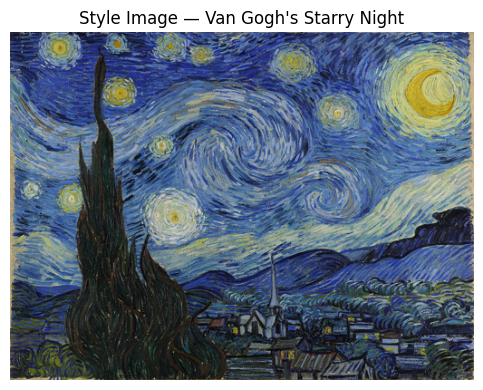

Style image loaded!


In [17]:
# Backup — download from GitHub raw content
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/leongatys/PytorchNeuralStyleTransfer/master/Images/vangogh_starry_night.jpg",
    "starry_night.jpg"
)

style_image = Image.open("starry_night.jpg").convert("RGB")
style_image = style_image.resize((512, 384))

plt.figure(figsize=(6, 4))
plt.imshow(style_image)
plt.title("Style Image — Van Gogh's Starry Night")
plt.axis('off')
plt.tight_layout()
plt.show()
print("Style image loaded!")

## Step 6: Neural Style Transfer — VGG Feature Extraction and Optimization

In [18]:
def get_features(image_tensor, model):
    layers = {
        '0' : 'conv1_1',
        '5' : 'conv2_1',
        '10': 'conv3_1',
        '19': 'conv4_1',
        '21': 'conv4_2',  # content layer
        '28': 'conv5_1'
    }
    features = {}
    x = image_tensor
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    return features


def gram_matrix(tensor):
    b, c, h, w = tensor.size()
    tensor = tensor.view(c, h * w)
    gram = torch.mm(tensor, tensor.t())
    return gram


def image_to_tensor(img):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )
    ])
    return transform(img).unsqueeze(0).to(device)


# Convert images to tensors
content_tensor = image_to_tensor(content_image)
style_tensor   = image_to_tensor(style_image)

# Extract features
content_features = get_features(content_tensor, vgg)
style_features   = get_features(style_tensor,   vgg)

# Compute gram matrices for style layers
style_grams = {layer: gram_matrix(style_features[layer])
               for layer in style_features}

# Start with a copy of content image
target = content_tensor.clone().requires_grad_(True)

# Style and content weights
style_weight   = 1e6
content_weight = 1

# Layer weights for style
style_weights = {
    'conv1_1': 1.0,
    'conv2_1': 0.75,
    'conv3_1': 0.2,
    'conv4_1': 0.2,
    'conv5_1': 0.2
}

optimizer = optim.Adam([target], lr=0.003)

print("Starting Neural Style Transfer optimization...")
steps = 300

for step in range(1, steps + 1):
    target_features = get_features(target, vgg)

    # Content loss
    content_loss = torch.mean(
        (target_features['conv4_2'] - content_features['conv4_2']) ** 2
    )

    # Style loss
    style_loss = 0
    for layer in style_weights:
        target_gram = gram_matrix(target_features[layer])
        style_gram  = style_grams[layer]
        layer_loss  = style_weights[layer] * torch.mean(
            (target_gram - style_gram) ** 2
        )
        style_loss += layer_loss

    # Total loss
    total_loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(f"Step [{step}/{steps}]  Total Loss: {total_loss.item():.2f}  "
              f"Content Loss: {content_loss.item():.4f}  "
              f"Style Loss: {style_loss.item():.4f}")

print("NST optimization complete!")

Starting Neural Style Transfer optimization...
Step [50/300]  Total Loss: 1017637874171904.00  Content Loss: 4.2158  Style Loss: 1017637888.0000
Step [100/300]  Total Loss: 372563649757184.00  Content Loss: 4.6722  Style Loss: 372563648.0000
Step [150/300]  Total Loss: 170379708465152.00  Content Loss: 4.9672  Style Loss: 170379712.0000
Step [200/300]  Total Loss: 96094390321152.00  Content Loss: 5.2961  Style Loss: 96094392.0000
Step [250/300]  Total Loss: 64544479117312.00  Content Loss: 5.5623  Style Loss: 64544480.0000
Step [300/300]  Total Loss: 48630346022912.00  Content Loss: 5.7695  Style Loss: 48630348.0000
NST optimization complete!


## Step 7: Display the Neural Style Transfer Result

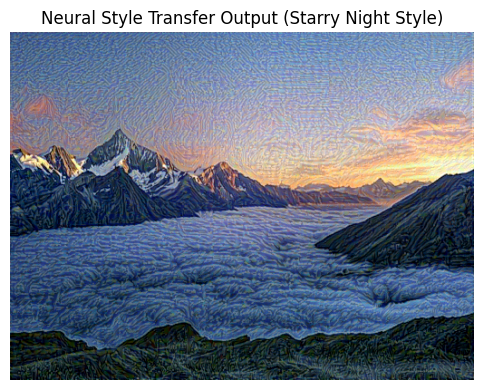

NST output saved!


In [19]:
def tensor_to_image(tensor):
    image = tensor.clone().detach()
    image = image.squeeze(0)
    image = image.cpu().numpy().transpose(1, 2, 0)

    # Denormalize
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    image = image * std + mean
    image = np.clip(image, 0, 1)
    return image

nst_output = tensor_to_image(target)
nst_image  = Image.fromarray((nst_output * 255).astype('uint8'))
nst_image.save("nst_output.jpg")

plt.figure(figsize=(6, 4))
plt.imshow(nst_output)
plt.title("Neural Style Transfer Output (Starry Night Style)")
plt.axis('off')
plt.tight_layout()
plt.show()
print("NST output saved!")

## Step 8: Compare the Results Side by Side — Original | CycleGAN | Neural Style Transfer

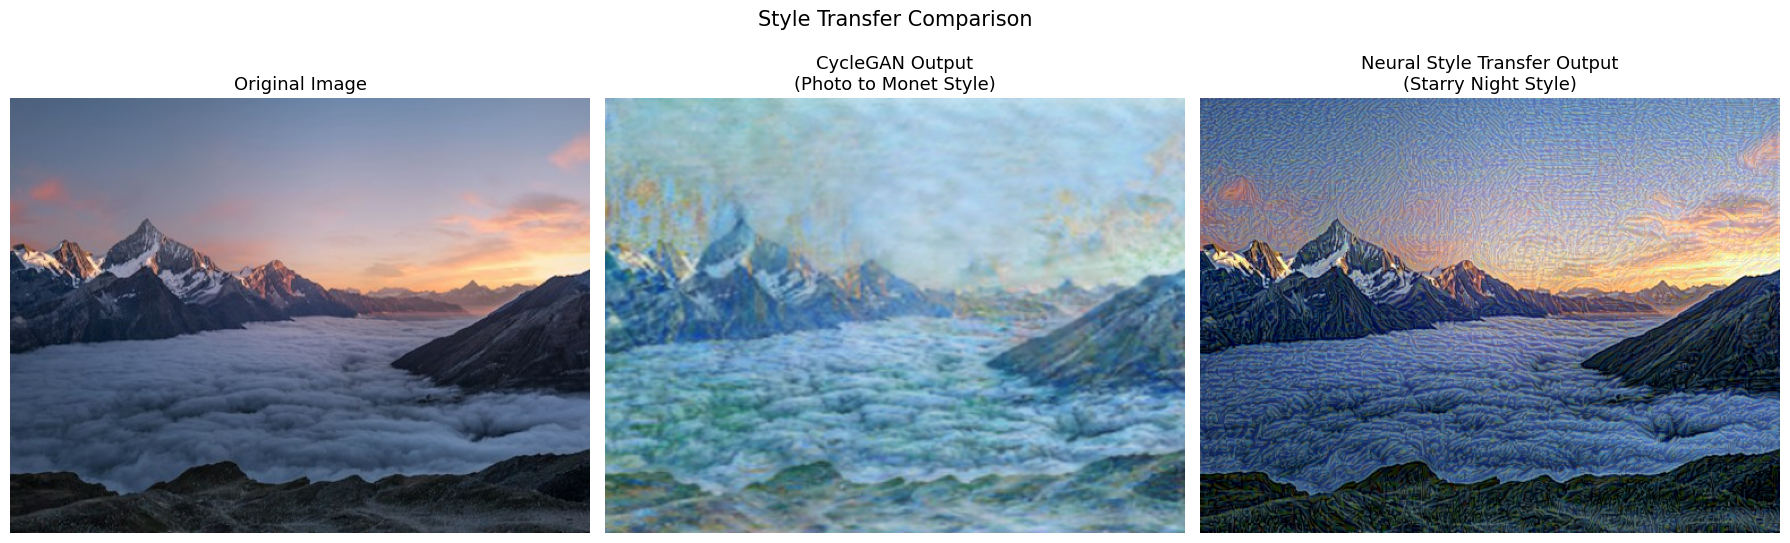

Comparison saved!


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(content_image)
axes[0].set_title("Original Image", fontsize=13)
axes[0].axis('off')

axes[1].imshow(cyclegan_image)
axes[1].set_title("CycleGAN Output\n(Photo to Monet Style)", fontsize=13)
axes[1].axis('off')

axes[2].imshow(nst_output)
axes[2].set_title("Neural Style Transfer Output\n(Starry Night Style)", fontsize=13)
axes[2].axis('off')

plt.suptitle("Style Transfer Comparison", fontsize=15)
plt.tight_layout()
plt.savefig("comparison.jpg", bbox_inches='tight')
plt.show()
print("Comparison saved!")

## Written Comparison

### Which method retained the original content more effectively?

Neural Style Transfer retained the original image content more closely. The mountain peaks, snow, cloud formations, and sunset sky remain clearly recognizable and structurally preserved in the NST result. In comparison, CycleGAN changes the overall colour scheme and texture more strongly. The warm orange tones of the sunset become a cooler blue-green Monet-like palette, while some smaller details in the clouds and foreground are reduced.

### Which method created a stronger style transformation?

CycleGAN created a more pronounced and comprehensive style transformation. The complete image takes on the appearance of a Monet-inspired impressionist painting, with painterly textures, soft colour transitions, and a consistent artistic appearance throughout. NST adds the swirling visual characteristics of *Starry Night*, but much of the photograph's original colour and lighting remains visible, so the result appears closer to a stylized photograph.

### What differences were observed between the two outputs?

The main difference is the way the two techniques apply artistic style. CycleGAN performs an end-to-end domain translation and learns to transform photographs into the Monet domain, allowing it to modify colours, textures, and lighting together. Neural Style Transfer follows a different process: it starts with the content image and repeatedly updates the pixel values so that the image matches the style statistics, represented through Gram matrices, of the selected style image. As a result, NST generally retains more of the original structure and colour information. CycleGAN also uses cycle-consistency loss, which encourages an image translated from the photo domain to the Monet domain and back to remain close to the original. This makes it possible to learn the domain transformation without paired examples and produce a broader domain-level style change.